# Certified Counterfactual Generation on 2D Spiral Data – K-Medoids Dataset Reduction

This notebook extends **3.2** by applying **k-medoids clustering** before building the atlas.
Instead of anchoring one polytope per training point, we first select *K* representative medoids
per class and build the atlas over those K points only.

**Why k-medoids (not k-means)?**  
Medoids are actual data points, so the polytope centers are guaranteed to be real observations
rather than synthetic cluster centroids. This preserves the semantic validity of each atlas cell.

**What we study:**
- How much coverage is lost when going from N → K polytopes per class?
- Does the atlas quality (Chebyshev radius, area ratio) degrade?
- How do counterfactual distances compare against the full atlas?

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from torch.utils.data import TensorDataset

import sys
sys.path.insert(0, '../src')
from models.classifiers import SimpleClassifier
from preimage_sampling import CertifiedAtlas

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

cmap = plt.colormaps.get_cmap('tab10')

Using device: cuda


## 2 – Load Data & Model

In [ ]:
dataset = torch.load('../data/TOY Spiral/train_spiral.pt', weights_only=True)
X_all = torch.stack([x for x, _ in dataset])
y_all = torch.tensor([y for _, y in dataset])
n_classes = len(set(y_all.numpy()))

print(f'Dataset: {len(dataset)} samples, {n_classes} classes')
print(f'Input dim: {X_all.shape[1]}')

# Load pre-trained classifier from Lightning checkpoint
from training.lit_classifier import LitClassifier
lit = LitClassifier.load_from_checkpoint(
    '../checkpoints/spiral_classifier/Spiral-Classifier-162-0.0327.ckpt',
    model=SimpleClassifier(num_classes=n_classes)
)
model = lit.model.to(device).eval()

# Verify accuracy
with torch.no_grad():
    preds = model(X_all.to(device)).argmax(dim=1).cpu()
    acc = (preds == y_all).float().mean()
print(f'Classifier accuracy: {acc*100:.1f}%')

## 3 – K-Medoids Dataset Reduction

We cluster each class independently into *K* groups and take the medoid (the actual data point
closest to the cluster centroid) as the representative for that group.

This reduces the atlas from $N$ polytopes to $K \cdot C$ polytopes, where $C$ is the number of
classes. The parameter `K_PER_CLASS` controls the compression ratio.

In [4]:
try:
    from sklearn_extra.cluster import KMedoids
    KMEDOIDS_BACKEND = 'sklearn_extra'
except ImportError:
    KMedoids = None
    KMEDOIDS_BACKEND = 'kmeans+nn'  # k-means centroids -> nearest actual point
    from sklearn.cluster import KMeans
    from sklearn.metrics import pairwise_distances

print(f'K-medoids backend: {KMEDOIDS_BACKEND}')

# ── Configuration ────────────────────────────────────────────────────────────
K_PER_CLASS = 80   # medoids per class  (original: 320 per class)

# ── Run clustering per class ─────────────────────────────────────────────────
medoid_X_list, medoid_y_list = [], []
medoid_indices_per_class = {}

for c in range(n_classes):
    mask = (y_all == c).numpy()
    X_c = X_all[mask].numpy()

    if KMEDOIDS_BACKEND == 'sklearn_extra':
        km = KMedoids(n_clusters=K_PER_CLASS, metric='euclidean',
                      method='alternate', random_state=SEED)
        km.fit(X_c)
        med_idx = km.medoid_indices_
    else:
        km = KMeans(n_clusters=K_PER_CLASS, random_state=SEED, n_init='auto')
        km.fit(X_c)
        dists = pairwise_distances(km.cluster_centers_, X_c)
        med_idx = dists.argmin(axis=1)

    medoid_indices_per_class[c] = med_idx
    X_med = torch.tensor(X_c[med_idx], dtype=torch.float32)
    medoid_X_list.append(X_med)
    medoid_y_list.append(torch.full((len(med_idx),), c, dtype=torch.long))
    print(f'  Class {c}: {mask.sum()} points  →  {len(med_idx)} medoids')

medoid_X_all = torch.cat(medoid_X_list)
medoid_y_all = torch.cat(medoid_y_list)
reduced_dataset = TensorDataset(medoid_X_all, medoid_y_all)

print(f'\nOriginal dataset : {len(dataset):4d} samples')
print(f'Reduced dataset  : {len(reduced_dataset):4d} samples '
      f'({100*len(reduced_dataset)/len(dataset):.0f}% of original)')

K-medoids backend: kmeans+nn
  Class 0: 320 points  →  80 medoids
  Class 1: 320 points  →  80 medoids
  Class 2: 320 points  →  80 medoids
  Class 3: 320 points  →  80 medoids
  Class 4: 320 points  →  80 medoids

Original dataset : 1600 samples
Reduced dataset  :  400 samples (25% of original)


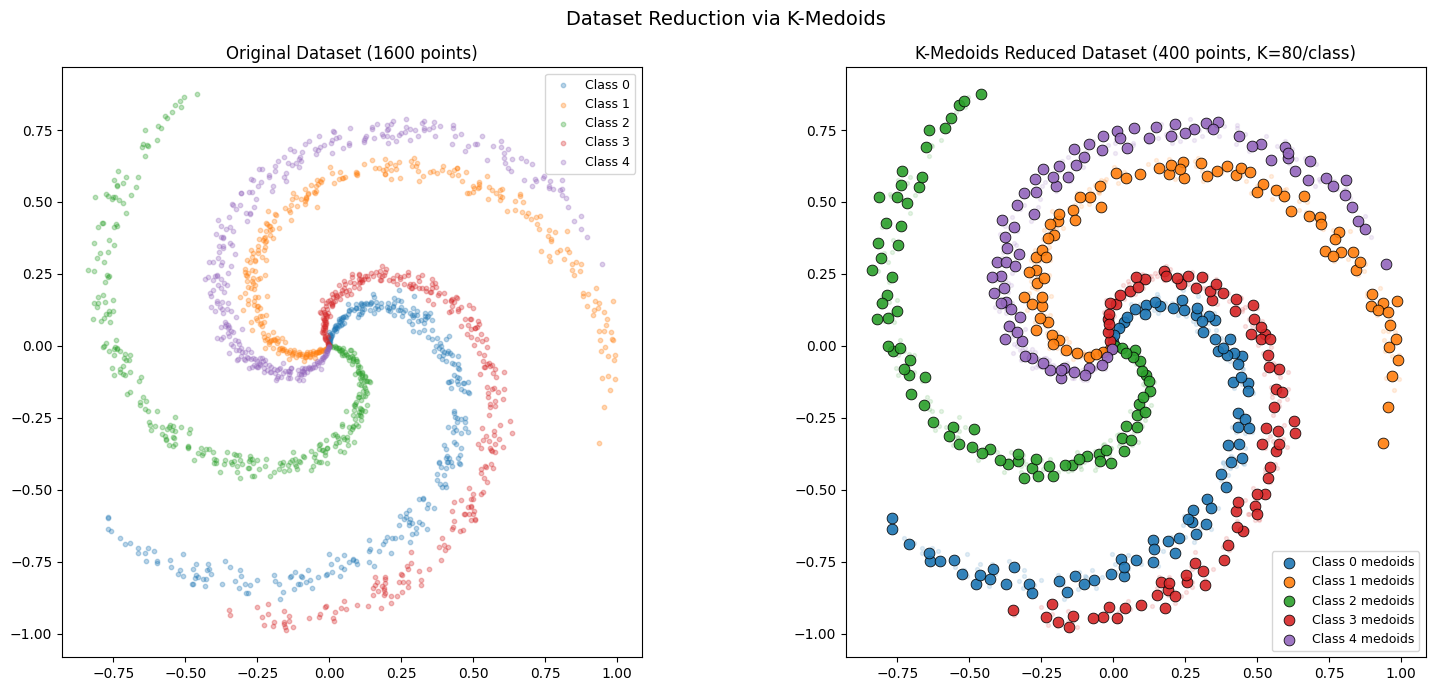

In [5]:
# ── Visualize: original data vs medoids ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
for c in range(n_classes):
    mask = y_all == c
    ax.scatter(X_all[mask, 0], X_all[mask, 1], s=10, alpha=0.3,
               c=[cmap(c)], label=f'Class {c}')
ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.set_title(f'Original Dataset ({len(dataset)} points)')

ax = axes[1]
for c in range(n_classes):
    mask = y_all == c
    ax.scatter(X_all[mask, 0], X_all[mask, 1], s=8, alpha=0.12,
               c=[cmap(c)])
    # Overlay medoids
    X_med = medoid_X_list[c]
    ax.scatter(X_med[:, 0], X_med[:, 1], s=60, alpha=0.9,
               c=[cmap(c)], edgecolors='black', linewidth=0.6,
               label=f'Class {c} medoids')
ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.set_title(f'K-Medoids Reduced Dataset ({len(reduced_dataset)} points, K={K_PER_CLASS}/class)')

plt.suptitle('Dataset Reduction via K-Medoids', fontsize=14)
plt.tight_layout()
plt.show()

## 4 – Build Certified Atlas on Reduced Dataset

We now build the atlas anchored at the *K* medoids per class instead of all N training points.
The polytope structure is otherwise identical:

$$P_i = \bigl\{\, \mathbf{x} \in \mathbb{R}^2 \;\big|\; A_i \mathbf{x} + \mathbf{b}_i \geq \mathbf{0}\bigr\} \;\cap\; \mathcal{B}_p(\mathbf{x}_i, \varepsilon)$$

For a fair comparison we also build a **full atlas** (all N points) and compare coverage and quality.

In [6]:
EPS  = 0.1
NORM = 1

from preimage_sampling import NearestOppositeClassClearanceStrategy

eps_strategy = NearestOppositeClassClearanceStrategy(alpha=0.45)


print('Building REDUCED atlas (k-medoids)...')
atlas_reduced = CertifiedAtlas(model, reduced_dataset, device)
# atlas_reduced.build(eps=EPS, norm=NORM, build_unions=True, verbose=True)
atlas_reduced.build(norm=NORM, build_unions=True, verbose=True, eps_strategy=eps_strategy)

print()
print('Building FULL atlas (all training points)...')
atlas_full = CertifiedAtlas(model, dataset, device)
atlas_full.build(eps=EPS, norm=NORM, build_unions=True, verbose=True)

Building REDUCED atlas (k-medoids)...
Building certified atlas (eps in [0.003196, 0.1875] (NearestOppositeClassClearanceStrategy), L1 norm)...
  Computing LiRPA bounds...


Computing bounds:   0%|          | 0/5 [00:00<?, ?it/s]/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/operators/linear.py:650: RuntimeWarning: divide by zero encountered in scalar divide
  dual_norm = np.float64(1.0) / (1 - 1.0 / norm)
Computing bounds: 100%|██████████| 5/5 [00:05<00:00,  1.13s/it]


  Building BVH spatial indices...
    Class 0: 80 polytopes, tree depth 8
    Class 1: 80 polytopes, tree depth 8
    Class 2: 80 polytopes, tree depth 8
    Class 3: 80 polytopes, tree depth 8
    Class 4: 80 polytopes, tree depth 8
  Building polygon unions...
Done! Total: 400 polytopes across 5 classes

Building FULL atlas (all training points)...
Building certified atlas (eps=0.1, L1 norm)...
  Computing LiRPA bounds...


Computing bounds:   0%|          | 0/5 [00:00<?, ?it/s]/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/operators/linear.py:650: RuntimeWarning: divide by zero encountered in scalar divide
  dual_norm = np.float64(1.0) / (1 - 1.0 / norm)
Computing bounds: 100%|██████████| 5/5 [00:00<00:00, 62.87it/s]


  Building BVH spatial indices...
    Class 0: 320 polytopes, tree depth 10
    Class 1: 320 polytopes, tree depth 10
    Class 2: 320 polytopes, tree depth 10
    Class 3: 320 polytopes, tree depth 10
    Class 4: 320 polytopes, tree depth 10
  Building polygon unions...
Done! Total: 1600 polytopes across 5 classes


CertifiedAtlas(n_classes=5, built)

## 5 – Preimage Approximation Quality Comparison

We compute the same diagnostic metrics as in notebook 3.2 for both atlases.

In [7]:
from preimage_sampling.geometry.polytopes import make_polygon

def compute_poly_metrics(atlas, label):
    """Return per-polytope metric rows for one class of an atlas."""
    d = 2
    N_MC = 5000
    bd = atlas.bounds[label]
    rows = []
    for i in range(len(bd['X'])):
        eps_i = float(bd['eps'][i])
        box_area = (2 * eps_i) ** 2
        center = bd['X'][i]
        lA_i   = bd['lA'][i]
        lbias_i = bd['lbias'][i]
        margins = lA_i @ center + lbias_i
        min_margin = margins.min()
        feasible = min_margin >= -1e-6

        cheb_r = 0.0
        vol_ratio = 0.0
        poly_area = 0.0
        if feasible:
            row_norms = np.maximum(np.linalg.norm(lA_i, axis=1), 1e-12)
            cheb_r = min(np.min(margins / row_norms), eps_i)
            samples = center + eps_i * (2 * np.random.rand(N_MC, d) - 1)
            vol_ratio = np.all(samples @ lA_i.T + lbias_i >= 0, axis=1).mean()
            try:
                poly = make_polygon(lA_i, lbias_i, center, eps_i)
                if poly is not None:
                    poly_area = poly.area
            except Exception:
                pass

        rows.append({
            'class': label,
            'feasible': feasible,
            'eps': eps_i,
            'cheb_r_ratio': cheb_r / eps_i if eps_i > 0 else 0,
            'volume_ratio': vol_ratio,
            'area_ratio': poly_area / box_area if box_area > 0 else 0,
            'polygon_area': poly_area,
        })
    return rows


records = []
for variant, atl in [('full', atlas_full), ('reduced', atlas_reduced)]:
    for c in range(n_classes):
        for row in compute_poly_metrics(atl, c):
            row['atlas'] = variant
            records.append(row)

poly_df = pd.DataFrame(records)

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'Atlas L{NORM} norm, 2D')
print()

for variant in ['full', 'reduced']:
    sub = poly_df[poly_df['atlas'] == variant]
    feas = sub[sub['feasible']]
    has_area = feas[feas['polygon_area'] > 1e-12]
    eps_vals = sub['eps']
    print(f'=== {variant.upper()} ATLAS ===')
    if eps_vals.nunique() == 1:
        print(f'  eps: {eps_vals.iloc[0]:.4g} (constant)')
    else:
        print(f'  eps: [{eps_vals.min():.4g}, {eps_vals.max():.4g}] (per-sample)')
    print(f'  Polytopes: {len(sub)} total, {len(feas)} feasible '
          f'({100*len(feas)/len(sub):.1f}%)')
    print(f'  Cheb r/eps (median) : {feas["cheb_r_ratio"].median():.2%}')
    print(f'  Volume ratio (median): {feas["volume_ratio"].median():.2%}')
    print(f'  Area/box   (median) : {has_area["area_ratio"].median():.2%}')
    print()

Atlas L1 norm, 2D

=== FULL ATLAS ===
  eps: 0.1 (constant)
  Polytopes: 1600 total, 1288 feasible (80.5%)
  Cheb r/eps (median) : 46.89%
  Volume ratio (median): 74.36%
  Area/box   (median) : 74.33%

=== REDUCED ATLAS ===
  eps: [0.003196, 0.1875] (per-sample)
  Polytopes: 400 total, 387 feasible (96.8%)
  Cheb r/eps (median) : 100.00%
  Volume ratio (median): 100.00%
  Area/box   (median) : 100.00%



INFO     19:01:25     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     19:01:25     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     19:01:25     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     19:01:25     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     19:01:25     [category.py:224] Using categorical units to plot a list o

/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


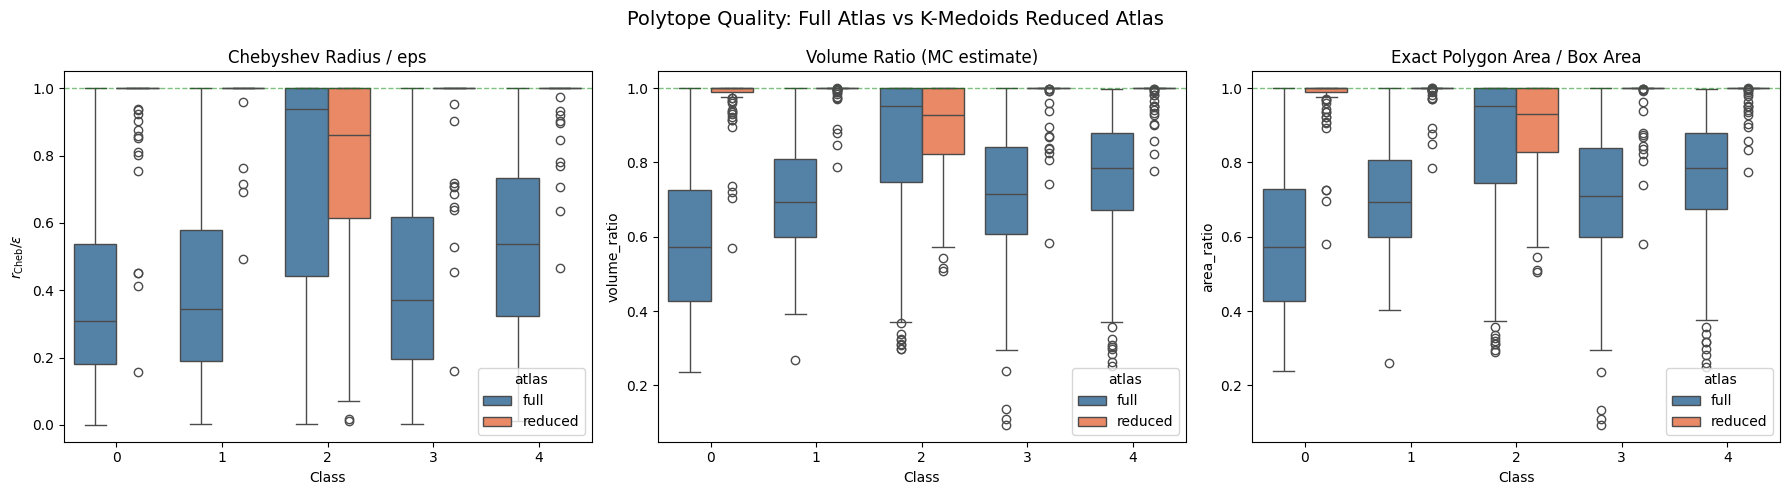

In [8]:
feas_df = poly_df[poly_df['feasible']]
area_df = feas_df[feas_df['polygon_area'] > 1e-12]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chebyshev radius ratio
sns.boxplot(ax=axes[0], x='class', y='cheb_r_ratio', hue='atlas',
            data=feas_df, palette={'full': 'steelblue', 'reduced': 'coral'})
axes[0].axhline(1.0, color='green', linestyle='--', alpha=0.5, linewidth=1)
axes[0].set_title('Chebyshev Radius / eps')
axes[0].set_xlabel('Class')
axes[0].set_ylabel(r'$r_{\mathrm{Cheb}} / \varepsilon$')

# Volume ratio
sns.boxplot(ax=axes[1], x='class', y='volume_ratio', hue='atlas',
            data=feas_df, palette={'full': 'steelblue', 'reduced': 'coral'})
axes[1].axhline(1.0, color='green', linestyle='--', alpha=0.5, linewidth=1)
axes[1].set_title('Volume Ratio (MC estimate)')
axes[1].set_xlabel('Class')

# Exact area ratio
sns.boxplot(ax=axes[2], x='class', y='area_ratio', hue='atlas',
            data=area_df, palette={'full': 'steelblue', 'reduced': 'coral'})
axes[2].axhline(1.0, color='green', linestyle='--', alpha=0.5, linewidth=1)
axes[2].set_title('Exact Polygon Area / Box Area')
axes[2].set_xlabel('Class')

plt.suptitle('Polytope Quality: Full Atlas vs K-Medoids Reduced Atlas', fontsize=14)
plt.tight_layout()
plt.show()

## 6 – Visualize Certified Regions

Side-by-side polygon union plots show how the certified coverage shrinks with fewer polytopes.

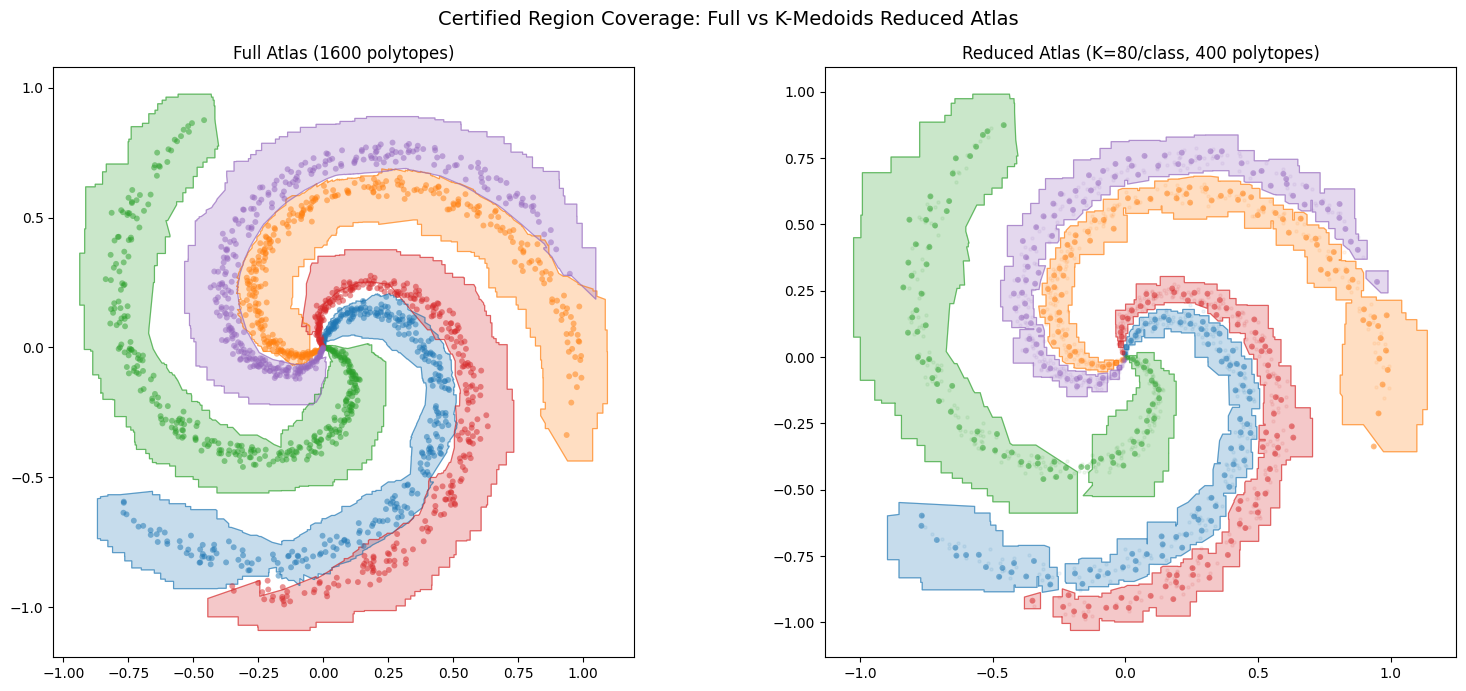

In [9]:
def plot_atlas(atlas, ax, alpha=0.3, show_data=True, title=''):
    for label in range(atlas.n_classes):
        color = cmap(label)
        if show_data:
            X = atlas.bounds[label]['X']
            ax.scatter(X[:, 0], X[:, 1], s=18, alpha=0.5, c=[color],
                       zorder=3, edgecolors='none')
        union = atlas.get_class_union(label)
        if union is None or union.is_empty:
            continue
        geoms = [union] if union.geom_type == 'Polygon' else list(union.geoms)
        for g in geoms:
            xs, ys = g.exterior.xy
            ax.fill(xs, ys, alpha=alpha, color=color)
            ax.plot(xs, ys, lw=0.8, color=color, alpha=0.6)
    ax.set_aspect('equal')
    if title:
        ax.set_title(title, fontsize=12)


fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_atlas(atlas_full, axes[0], alpha=0.25,
           title=f'Full Atlas ({len(dataset)} polytopes)')
plot_atlas(atlas_reduced, axes[1], alpha=0.25,
           title=f'Reduced Atlas (K={K_PER_CLASS}/class, {len(reduced_dataset)} polytopes)')

# Overlay full-data scatter (faint) on reduced plot for reference
for c in range(n_classes):
    mask = y_all == c
    axes[1].scatter(X_all[mask, 0], X_all[mask, 1], s=5, alpha=0.08,
                    c=[cmap(c)], zorder=1)

plt.suptitle('Certified Region Coverage: Full vs K-Medoids Reduced Atlas', fontsize=14)
plt.tight_layout()
plt.show()

## 7 – Generate Counterfactuals

We query both atlases for the same set of query points and compare distances.

In [10]:
source_class = 0
n_queries = 10

# Use query points from the FULL atlas (original training data)
query_points = atlas_full.bounds[source_class]['X'][:n_queries]

print(f'Generating counterfactuals for {n_queries} queries from class {source_class}\n')

cf_rows = []
for target_class in range(n_classes):
    if target_class == source_class:
        continue

    for i, x0 in enumerate(query_points):
        res_full    = atlas_full.find_counterfactual(x0, target_class, method='bvh')
        res_reduced = atlas_reduced.find_counterfactual(x0, target_class, method='bvh')

        cf_rows.append({
            'target': target_class,
            'query_idx': i,
            'dist_full':    res_full.distance    if res_full.success    else np.nan,
            'dist_reduced': res_reduced.distance if res_reduced.success else np.nan,
            'qp_full':      res_full.n_qp_solved,
            'qp_reduced':   res_reduced.n_qp_solved,
            'success_full':    res_full.success,
            'success_reduced': res_reduced.success,
        })

cf_df = pd.DataFrame(cf_rows)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f'{"Target":>7} {"Full ok":>9} {"Red. ok":>9} '
      f'{"Dist full":>11} {"Dist red.":>11} {"QP full":>9} {"QP red.":>9}')
print('-' * 75)
for tc in range(n_classes):
    if tc == source_class:
        continue
    sub = cf_df[cf_df['target'] == tc]
    print(f'{tc:>7d} '
          f'{sub["success_full"].sum():>4d}/{len(sub):<4d} '
          f'{sub["success_reduced"].sum():>4d}/{len(sub):<4d} '
          f'{sub["dist_full"].mean():>11.4f} '
          f'{sub["dist_reduced"].mean():>11.4f} '
          f'{sub["qp_full"].mean():>9.1f} '
          f'{sub["qp_reduced"].mean():>9.1f}')

Generating counterfactuals for 10 queries from class 0

 Target   Full ok   Red. ok   Dist full   Dist red.   QP full   QP red.
---------------------------------------------------------------------------
      1   10/10     10/10        0.5257      0.5263      60.0       3.1
      2   10/10     10/10        0.2202      0.2276      23.5       4.7
      3   10/10     10/10        0.1179      0.1162      40.8       2.2
      4   10/10     10/10        0.4653      0.5161      41.8       1.7


INFO     19:02:15     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     19:02:15     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Median distance ratio (reduced / full): 1.0039
  > 1.0 (penalty): 23/40 CFs
  = 1.0 (same):    0/40 CFs
  < 1.0 (better):  17/40 CFs


/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


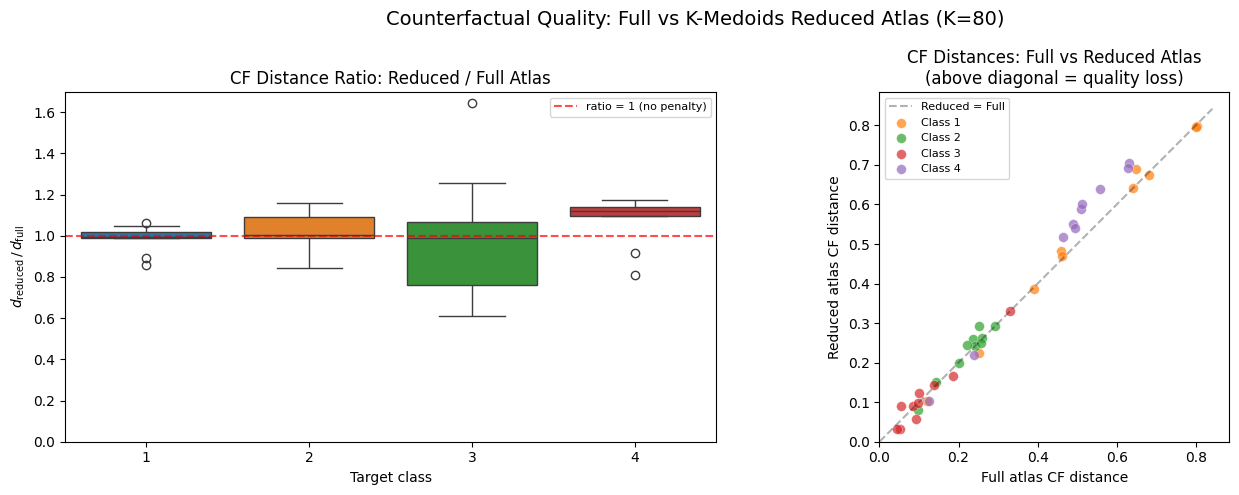

In [11]:
# ── Distance penalty of reduction ─────────────────────────────────────────────
both_ok = cf_df[cf_df['success_full'] & cf_df['success_reduced']].copy()
both_ok['dist_ratio'] = both_ok['dist_reduced'] / both_ok['dist_full']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distance ratio boxplot
ax = axes[0]
sns.boxplot(ax=ax, x='target', y='dist_ratio', data=both_ok,
            hue='target', palette='tab10', legend=False)
ax.axhline(1.0, color='red', linestyle='--', alpha=0.7, linewidth=1.5,
           label='ratio = 1 (no penalty)')
ax.set_xlabel('Target class')
ax.set_ylabel(r'$d_{\mathrm{reduced}}\,/\,d_{\mathrm{full}}$')
ax.set_title('CF Distance Ratio: Reduced / Full Atlas')
ax.set_ylim(bottom=0)
ax.legend(fontsize=8)

# Scatter: full vs reduced distances
ax = axes[1]
max_val = max(both_ok['dist_full'].max(), both_ok['dist_reduced'].max()) * 1.05
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Reduced = Full')
for tc in both_ok['target'].unique():
    sub = both_ok[both_ok['target'] == tc]
    ax.scatter(sub['dist_full'], sub['dist_reduced'], c=[cmap(tc)],
               alpha=0.7, s=50, label=f'Class {tc}', edgecolors='white', linewidth=0.3)
ax.set_xlabel('Full atlas CF distance')
ax.set_ylabel('Reduced atlas CF distance')
ax.set_title('CF Distances: Full vs Reduced Atlas\n(above diagonal = quality loss)')
ax.legend(fontsize=8)
ax.set_aspect('equal')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

print(f'Median distance ratio (reduced / full): {both_ok["dist_ratio"].median():.4f}')
print(f'  > 1.0 (penalty): {(both_ok["dist_ratio"] > 1.001).sum()}/{len(both_ok)} CFs')
print(f'  = 1.0 (same):    {((both_ok["dist_ratio"] >= 0.999) & (both_ok["dist_ratio"] <= 1.001)).sum()}/{len(both_ok)} CFs')
print(f'  < 1.0 (better):  {(both_ok["dist_ratio"] < 0.999).sum()}/{len(both_ok)} CFs')

plt.suptitle(f'Counterfactual Quality: Full vs K-Medoids Reduced Atlas (K={K_PER_CLASS})', fontsize=14)
plt.tight_layout()
plt.show()

## 8 – Coverage Analysis: Fraction of Space Covered

We sample random points and measure what fraction fall inside at least one polytope in each atlas.

In [12]:
from shapely.geometry import Point

# ── Compute union areas per class ─────────────────────────────────────────────
print(f'Union area coverage per class (eps={EPS}):\n')
print(f'{"Class":>6} {"Full area":>12} {"Reduced area":>14} {"Coverage ratio":>16}')
print('-' * 52)

for c in range(n_classes):
    u_full    = atlas_full.get_class_union(c)
    u_reduced = atlas_reduced.get_class_union(c)
    area_full    = u_full.area    if u_full    is not None else 0.0
    area_reduced = u_reduced.area if u_reduced is not None else 0.0
    ratio = area_reduced / area_full if area_full > 0 else 0.0
    print(f'{c:>6d} {area_full:>12.4f} {area_reduced:>14.4f} {ratio:>15.1%}')

# ── Total area ────────────────────────────────────────────────────────────────
from shapely.ops import unary_union
all_unions_full    = [atlas_full.get_class_union(c)    for c in range(n_classes)]
all_unions_reduced = [atlas_reduced.get_class_union(c) for c in range(n_classes)]
total_full    = unary_union([u for u in all_unions_full    if u is not None]).area
total_reduced = unary_union([u for u in all_unions_reduced if u is not None]).area
print(f'\nTotal certified area:')
print(f'  Full atlas   : {total_full:.4f}')
print(f'  Reduced atlas: {total_reduced:.4f}  ({total_reduced/total_full:.1%} of full)')

Union area coverage per class (eps=0.1):

 Class    Full area   Reduced area   Coverage ratio
----------------------------------------------------
     0       0.4007         0.3414           85.2%
     1       0.5016         0.3678           73.3%
     2       0.6443         0.7265          112.7%
     3       0.4870         0.2701           55.5%
     4       0.5323         0.2856           53.7%

Total certified area:
  Full atlas   : 2.5544
  Reduced atlas: 1.9913  (78.0% of full)


## 9 – Effect of K: Sweep Over Compression Ratios

We build atlases for several values of `K_PER_CLASS` and track coverage and median CF distance.

In [13]:
import warnings
warnings.filterwarnings('ignore')

K_VALUES = [10, 25, 50, 100, 160, 320]  # 320 = full dataset per class

sweep_rows = []

for K in K_VALUES:
    # Build reduced dataset
    mX, mY = [], []
    for c in range(n_classes):
        mask = (y_all == c).numpy()
        X_c = X_all[mask].numpy()
        k_actual = min(K, len(X_c))

        if KMEDOIDS_BACKEND == 'sklearn_extra':
            km = KMedoids(n_clusters=k_actual, metric='euclidean',
                          method='alternate', random_state=SEED)
            km.fit(X_c)
            med_idx = km.medoid_indices_
        else:
            km = KMeans(n_clusters=k_actual, random_state=SEED, n_init='auto')
            km.fit(X_c)
            med_idx = pairwise_distances(km.cluster_centers_, X_c).argmin(axis=1)

        mX.append(torch.tensor(X_c[med_idx], dtype=torch.float32))
        mY.append(torch.full((k_actual,), c, dtype=torch.long))

    ds_k = TensorDataset(torch.cat(mX), torch.cat(mY))

    atl = CertifiedAtlas(model, ds_k, device)
    atl.build(eps=EPS, norm=NORM, build_unions=True, verbose=False)

    # Coverage area
    total_area = sum(
        (atl.get_class_union(c).area if atl.get_class_union(c) is not None else 0.0)
        for c in range(n_classes)
    )

    # Median CF distance (class 0 -> all)
    dists = []
    for tc in range(n_classes):
        if tc == source_class:
            continue
        for x0 in query_points:
            r = atl.find_counterfactual(x0, tc, method='bvh')
            if r.success:
                dists.append(r.distance)

    sweep_rows.append({
        'K': K,
        'n_polytopes': len(ds_k),
        'coverage_area': total_area,
        'med_cf_dist': np.median(dists) if dists else np.nan,
        'success_rate': len(dists) / (n_queries * (n_classes - 1)),
    })
    print(f'K={K:3d}: area={total_area:.3f}, '
          f'med dist={sweep_rows[-1]["med_cf_dist"]:.4f}, '
          f'success={sweep_rows[-1]["success_rate"]:.0%}')

sweep_df = pd.DataFrame(sweep_rows)

Computing bounds: 100%|██████████| 5/5 [00:00<00:00, 56.22it/s]


K= 10: area=1.255, med dist=0.2991, success=100%


Computing bounds: 100%|██████████| 5/5 [00:00<00:00, 67.16it/s]


K= 25: area=1.879, med dist=0.2816, success=100%


Computing bounds: 100%|██████████| 5/5 [00:00<00:00, 69.65it/s]


...

K=100: area=2.398, med dist=0.2588, success=100%


Computing bounds: 100%|██████████| 5/5 [00:00<00:00, 48.29it/s]


K=160: area=2.503, med dist=0.2552, success=100%


Computing bounds: 100%|██████████| 5/5 [00:00<00:00, 57.86it/s]


K=320: area=2.566, med dist=0.2552, success=100%


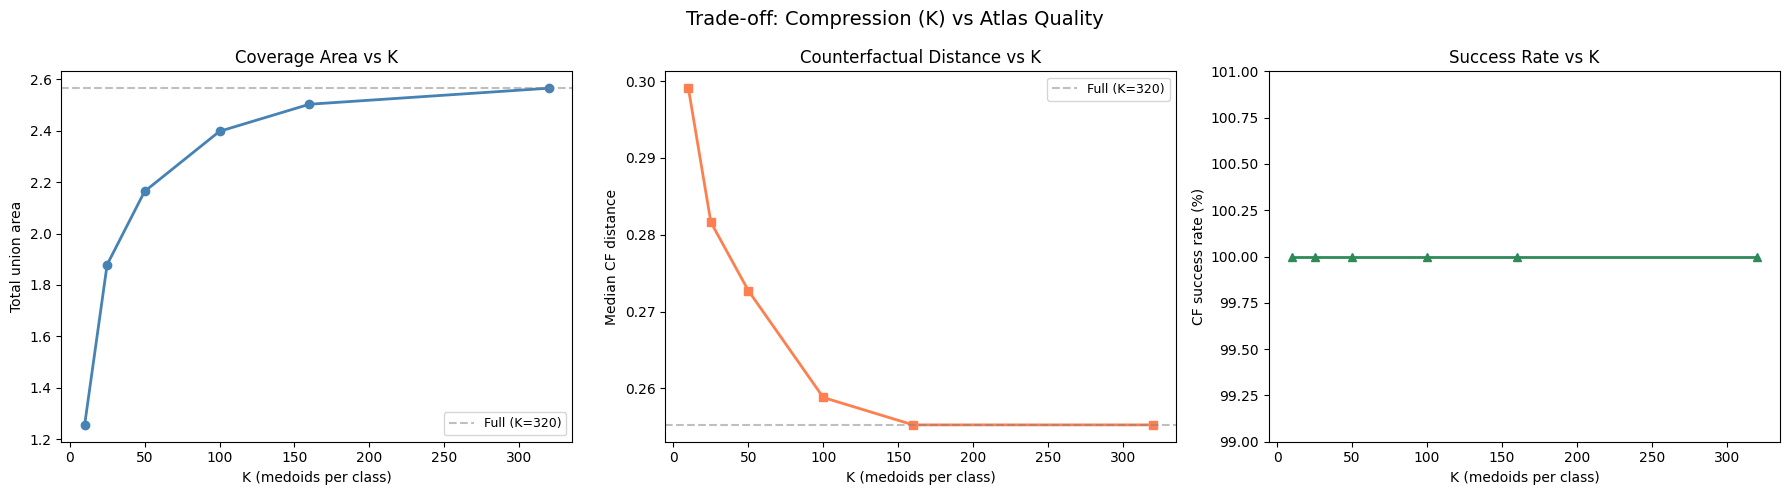

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(sweep_df['K'], sweep_df['coverage_area'], 'o-', color='steelblue', linewidth=2)
ax.axhline(sweep_df.loc[sweep_df['K'] == 320, 'coverage_area'].iloc[0],
           color='gray', linestyle='--', alpha=0.5, label='Full (K=320)')
ax.set_xlabel('K (medoids per class)')
ax.set_ylabel('Total union area')
ax.set_title('Coverage Area vs K')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(sweep_df['K'], sweep_df['med_cf_dist'], 's-', color='coral', linewidth=2)
ax.axhline(sweep_df.loc[sweep_df['K'] == 320, 'med_cf_dist'].iloc[0],
           color='gray', linestyle='--', alpha=0.5, label='Full (K=320)')
ax.set_xlabel('K (medoids per class)')
ax.set_ylabel('Median CF distance')
ax.set_title('Counterfactual Distance vs K')
ax.legend(fontsize=9)

ax = axes[2]
ax.plot(sweep_df['K'], sweep_df['success_rate'] * 100, '^-', color='seagreen', linewidth=2)
ax.set_xlabel('K (medoids per class)')
ax.set_ylabel('CF success rate (%)')
ax.set_title('Success Rate vs K')
y_min = max(sweep_df['success_rate'].min() * 100 * 0.99, 0)
ax.set_ylim(y_min, 101)

plt.suptitle('Trade-off: Compression (K) vs Atlas Quality', fontsize=14)
plt.tight_layout()
plt.show()

## Summary

K-medoids reduces the atlas from **N polytopes** to **K × C polytopes** while preserving
the semantic validity of each cell centre (medoids are real data points).

Key take-aways:
- **Coverage degrades gracefully** with decreasing K – the sweep plot shows the elbow.
- **Counterfactual distances increase modestly** because the polytope grid becomes coarser.
- **Query speed** scales as O(K log K) with the BVH, so smaller atlases are faster.
- A practical choice is the **elbow of the coverage-vs-K curve**, balancing speed and quality.